## Setup

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.status()

  Activating project at `~/Documents/Carnegie-Mellon/Chatterjee Group/Programming/WignerMolecule.jl/high-temp`


Status `~/Documents/Carnegie-Mellon/Chatterjee Group/Programming/WignerMolecule.jl/high-temp/Project.toml`
⌃ [13f3f980] CairoMakie v0.15.10
  [074ae576] CarloAnalysis v1.0.0-DEV `https://github.com/PatXue/CarloAnalysis.jl#main`
  [a93c6f00] DataFrames v1.8.2
  [033835bb] JLD2 v0.6.4
⌅ [ee78f7c6] Makie v0.24.10
  [eff96d63] Measurements v2.14.1
⌃ [295af30f] Revise v3.14.3
  [a601b020] WignerMolecule v1.0.0-DEV `..`
  [37e2e46d] LinearAlgebra v1.12.0
Info Packages marked with ⌃ and ⌅ have new versions available. Those with ⌃ may be upgradable, but those with ⌅ are restricted by compatibility constraints from upgrading. To see why use `status --outdated`


In [2]:
if !@isdefined Expectations
    include("Expectation.jl")
end

Main.Expectations

In [3]:
using .Expectations
using CairoMakie
using CarloAnalysis
using DataFrames
using JLD2
using LinearAlgebra
using Makie
using Measurements

In [ ]:
function Measurements.measurement(e::Expectation)
    return e.val ± e.err
end

function cumulant(moms::Vector{T}, ord) where {T <: Real}
    M = Matrix{T}(undef, ord, ord)
    for I in eachindex(IndexCartesian(), M)
        i, j = Tuple(I)
        mom = i-j < 0 ? 1 : moms[i-j+1]
        M[I] = mom * binomial(i-1, max(j-2, 0))
    end
    return (-1)^(ord+1) * det(M)
end

function cumulant(As, Hs, ord)
    if ord == 1
        cumulant = As[1]
    elseif ord == 2
        cumulant = As[2] - Hs[1]*As[1]
    elseif ord == 3
        cumulant = As[3] - 2*Hs[1]*As[2] - Hs[2]*As[1] + 2*Hs[1]^2*As[1]
    elseif ord == 4
        cumulant = As[4] - 3*Hs[1]*As[3] - 3*Hs[2]As[2] - Hs[3]*As[1] +
            6*Hs[1]^2*As[2] + 6*Hs[2]*Hs[1]*As[1] - 6*Hs[1]^3*As[1]
    else
        cumulant = 0 ± 0
    end
    return cumulant
end


"""
    getexpansion(name, ord)

Read high-T expansion coefficients for energy from JLD2 file to order ord,
returns closure accepting T
"""
function getexpansion(name, ord; L::Int=8)
    all_data = load("expectations.jld2")
    energies = [measurement(all_data["$name/HH$i"]) for i in 0:ord]
    cumulants = [cumulant(energies, i) for i in 1:(ord+1)]
    return T -> getfield.(sum([(-1/T)^i / factorial(i) for i in 0:ord] .* cumulants), :val) ./ L^2
end

"""
    getexpansion(name, ord, symbol)

TBW
"""
function getexpansion(name, ord, symbol::String)
    all_data = load("expectations.jld2")
    As = [measurement(all_data["$name/$(symbol)H$i"]) for i in 0:ord]
    Hs = [measurement(all_data["$name/HH$i"]) for i in 0:ord]
    cumulants = getfield.([cumulant(As, Hs, i) for i in 1:(ord+1)], :val)
    return T -> sum([(-1/T)^i / factorial(i) for i in 0:ord] .* cumulants)
end

getexpansion

## Stripe

In [5]:
results = JobResult("../jobs", "stripe-high-t")
transform!(results.data, :T => (T -> 1 ./ T) => :β)
results

JobResult("../jobs", "stripe-high-t", 17×53 DataFrame
 Row │ ηk_Γ                               ηk_corr_half_K                     M ⋯
     │ Array…                             Array…                             M ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…    ⋯
   2 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…  -
   3 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…
   4 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…
   5 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…  - ⋯
   6 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…  -
   7 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  -
   8 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…
  ⋮  │                 ⋮                                  ⋮                 

In [6]:
max_T = maximum(results.data[:, :T])
min_T = minimum(results.data[:, :T])

0.04

In [7]:
all_data = load("expectations.jld2")
display([cumulant([measurement(all_data["stripe/HH$i"]) for i in 0:4],i) for i in 1:4])
display([cumulant([measurement(all_data["stripe/sH$i"]) for i in 0:4],i) for i in 1:4])
display([cumulant([measurement(all_data["stripe/ηH$i"]) for i in 0:4],i) for i in 1:4])

4-element Vector{Measurement{Float64}}:
 -0.0013 ± 0.001
  2.1513 ± 0.0022
  -0.275 ± 0.011
  0.0081 ± 0.043

4-element Vector{Measurement{Float64}}:
 0.0156185 ± 6.3e-6
 -0.001417 ± 1.9e-5
  0.033796 ± 4.2e-5
  -0.01392 ± 0.00016

4-element Vector{Measurement{Float64}}:
 0.0104167 ± 7.3e-6
 -0.000133 ± 1.5e-5
  0.022551 ± 3.6e-5
  -0.00397 ± 0.00013

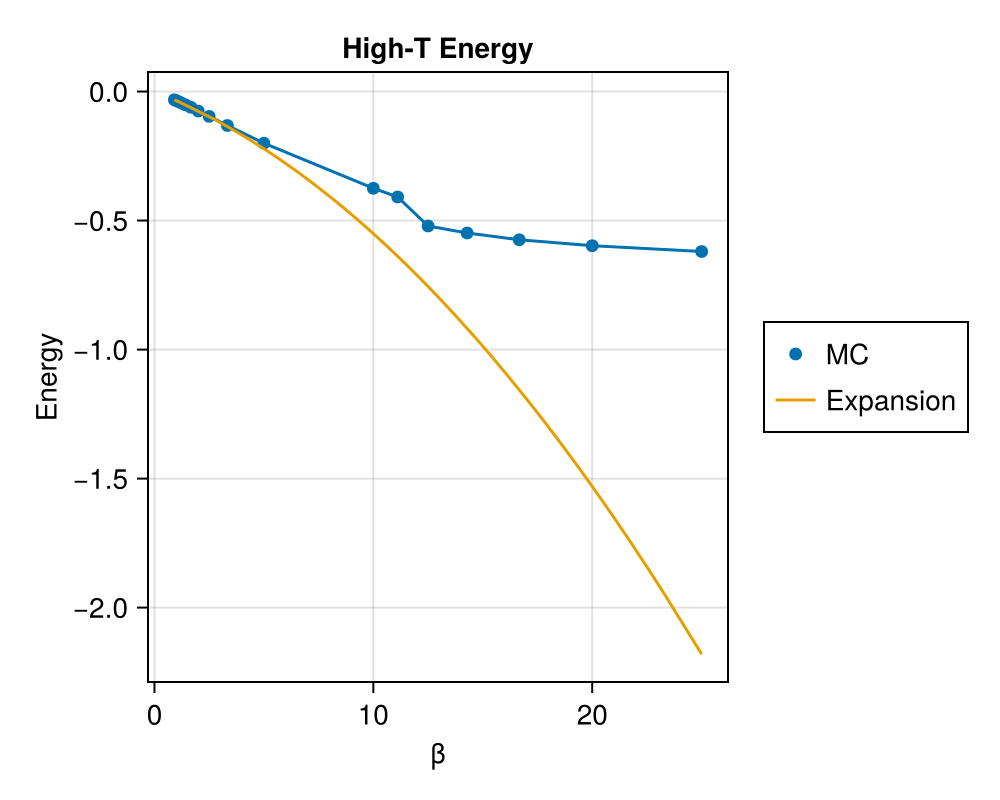

In [17]:
fig = Figure(size=(500,400))
fig[1,1] = ax1 = Axis(fig, title="High-T Energy", xlabel="β", ylabel="Energy")
generate_plot!(ax1, :β, :Energy, results.data, label="MC")
lines!(ax1, (1/max_T)..(1/min_T), getexpansion("stripe", 2) ∘ (T -> 1/T), label="Expansion")
Legend(fig[1,2], ax1)
fig

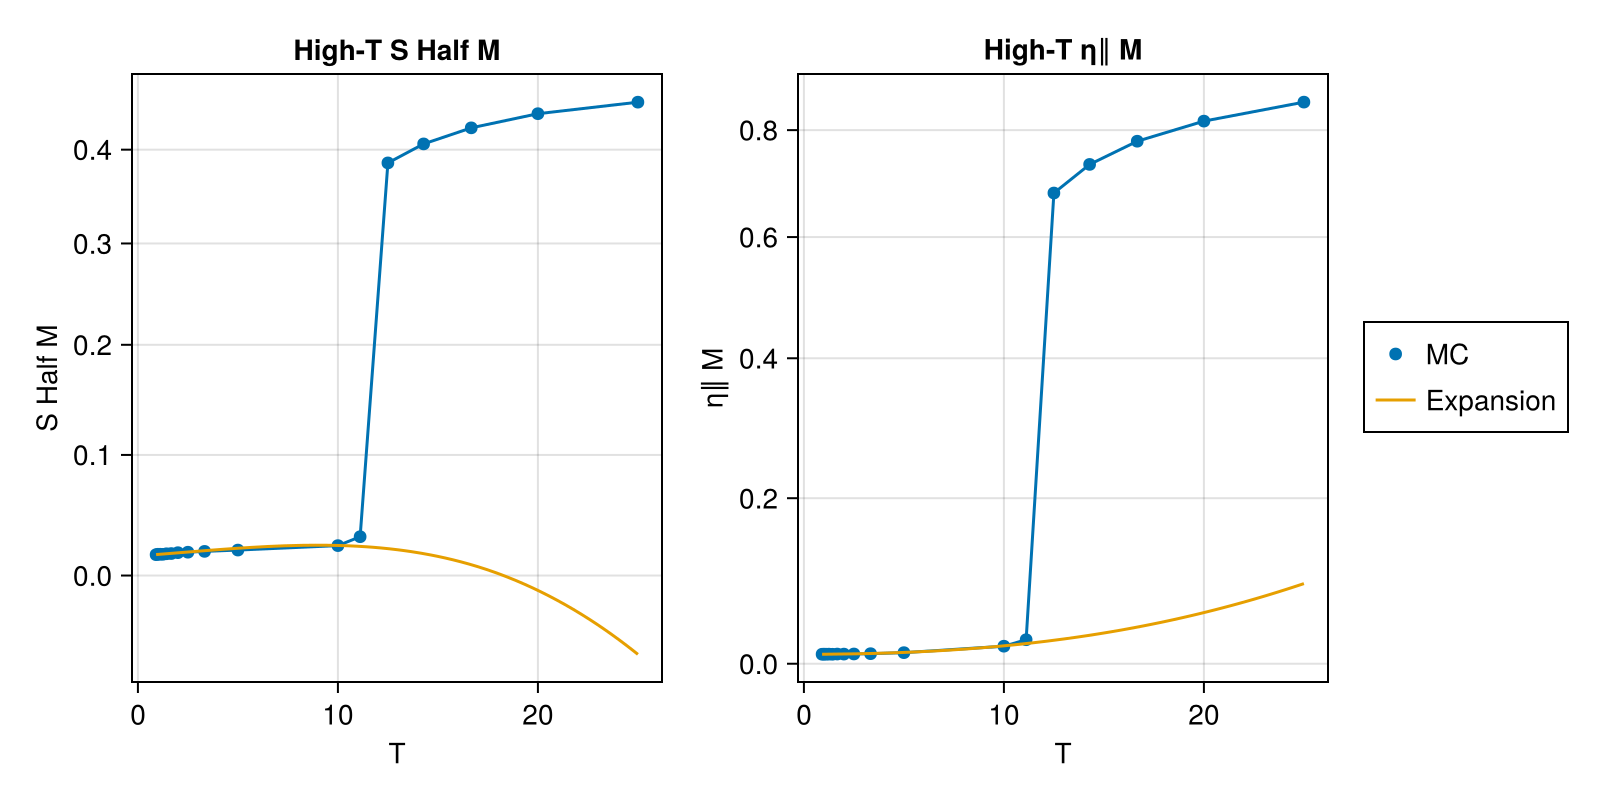

In [16]:
fig = Figure(size=(800,400))
fig[1,1] = ax1 = Axis(fig, title="High-T S Half M", xlabel="T", ylabel="S Half M", yscale=Makie.pseudolog10)
generate_plot!(ax1, :β, :sk_corr_half_M, results.data)
lines!(ax1, (1/max_T)..(1/min_T), getexpansion("stripe", 3, "s") ∘ (T -> 1/T), label="Expansion")
fig[1,2] = ax2 = Axis(fig, title="High-T η∥ M", xlabel="T", ylabel="η∥ M", yscale=Makie.pseudolog10)
generate_plot!(ax2, :β, :ηk_corr_M, results.data, label="MC") do ηk
    real.(getindex.(ηk, 1, 1) + getindex.(ηk, 2, 2))
end
lines!(ax2, (1/max_T)..(1/min_T), getexpansion("stripe", 3, "η") ∘ (T -> 1/T), label="Expansion")
Legend(fig[1,3], ax2)
fig

## FM

In [39]:
results = JobResult("../jobs", "fm-high-t")

JobResult("../jobs", "fm-high-t", 22×52 DataFrame
 Row │ ηk_Γ                               ηk_corr_half_K                     M ⋯
     │ Array…                             Array…                             M ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  - ⋯
   2 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…
   3 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  -
   4 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  -
   5 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…    ⋯
   6 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…
   7 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  -
   8 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  -
  ⋮  │                 ⋮                                  ⋮                  

In [40]:
max_T = maximum(results.data[:, :T])
min_T = minimum(results.data[:, :T])

0.05

In [41]:
all_data = load("expectations.jld2")
display([cumulant([measurement(all_data["fm/HH$i"]) for i in 0:4],i) for i in 1:4])
display([cumulant([measurement(all_data["fm/sH$i"]) for i in 0:4],i) for i in 1:4])
display([cumulant([measurement(all_data["fm/ηH$i"]) for i in 0:4],i) for i in 1:4])

4-element Vector{Measurement{Float64}}:
 0.00062 ± 0.00065
 0.85455 ± 0.00085
 -0.0237 ± 0.0027
 0.00064 ± 0.0067

4-element Vector{Measurement{Float64}}:
 0.0156164 ± 8.9e-6
 -0.001898 ± 1.4e-5
  0.013703 ± 2.0e-5
 -0.005509 ± 4.8e-5

4-element Vector{Measurement{Float64}}:
 0.0104175 ± 7.3e-6
 0.0001227 ± 9.5e-6
  0.008818 ± 1.4e-5
   -3.0e-5 ± 3.1e-5

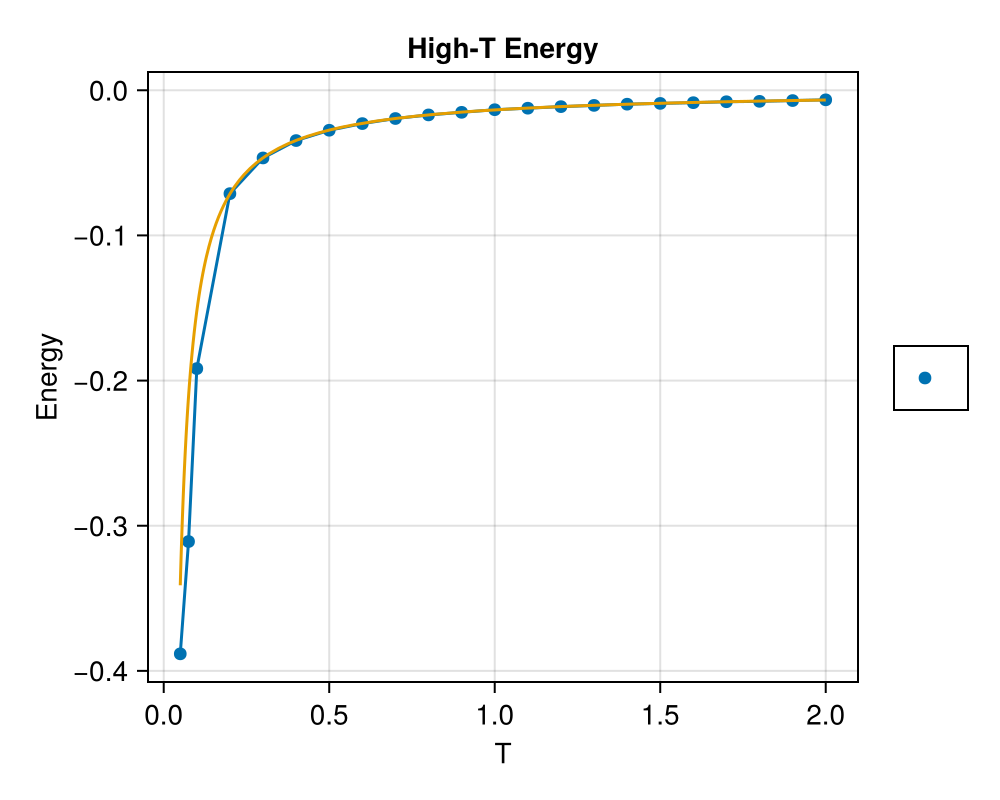

In [42]:
fig = Figure(size=(500,400))
fig[1,1] = ax1 = Axis(fig, title="High-T Energy", xlabel="T", ylabel="Energy")
generate_plot!(ax1, :T, :Energy, results.data)
lines!(ax1, min_T..max_T, getexpansion("fm", 2))
Legend(fig[1,2], ax1)
fig

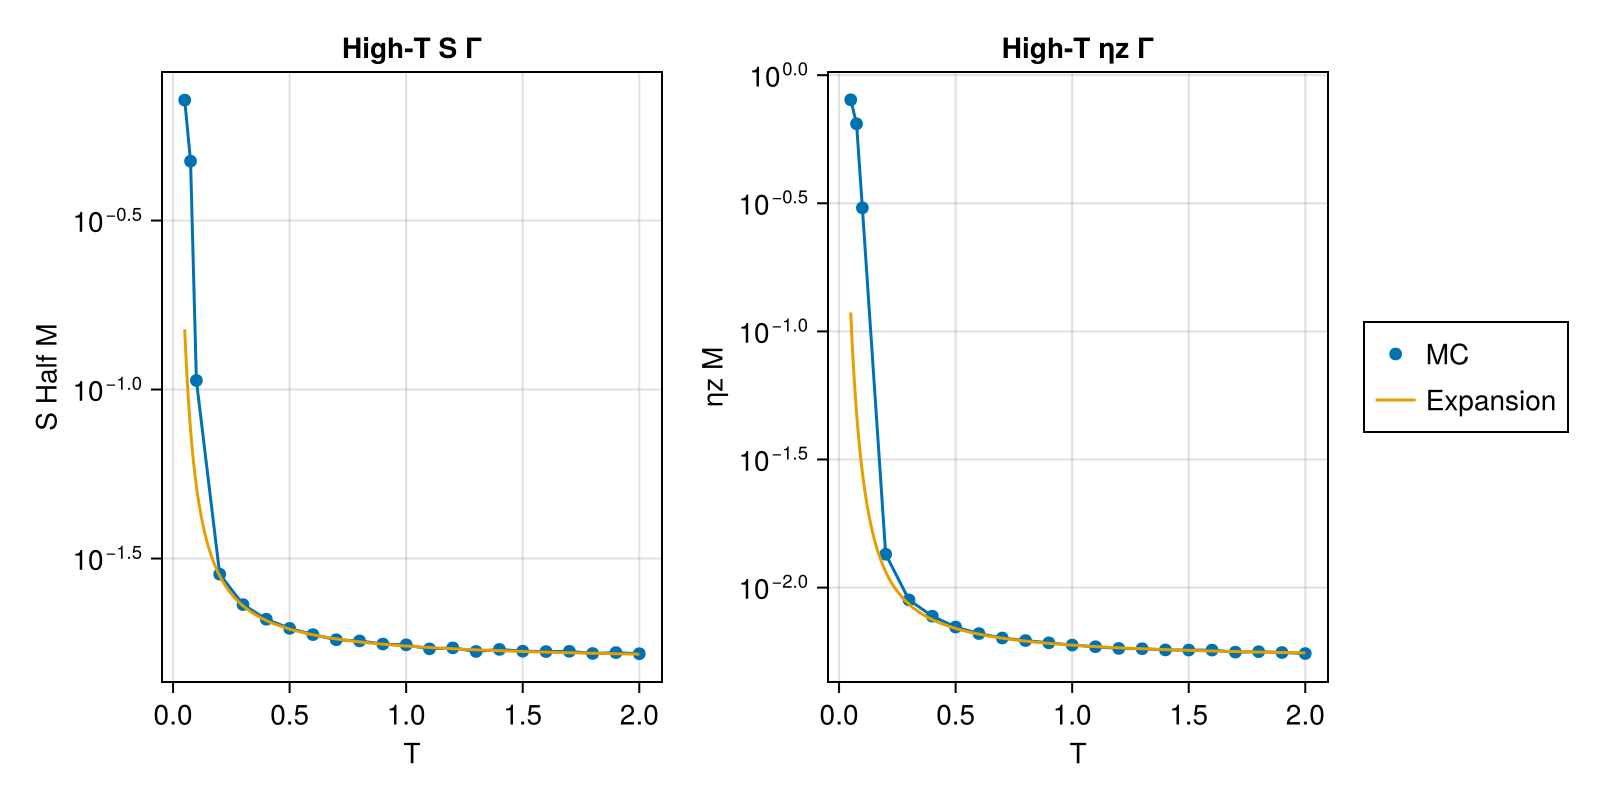

In [43]:
fig = Figure(size=(800,400))
fig[1,1] = ax1 = Axis(fig, title="High-T S Γ", xlabel="T", ylabel="S Half M", yscale=log10)
generate_plot!(ax1, :T, :sk_corr_Γ, results.data)
lines!(ax1, min_T..max_T, getexpansion("fm", 3, "s"))
fig[1,2] = ax2 = Axis(fig, title="High-T ηz Γ", xlabel="T", ylabel="ηz M", yscale=log10)
generate_plot!(ax2, :T, :ηk_corr_Γ, results.data, label="MC") do ηk
    real.(getindex.(ηk, 3, 3))
end
lines!(ax2, min_T..max_T, getexpansion("fm", 3, "ηz"), label="Expansion")
Legend(fig[1,3], ax2)
fig

## AFM-FE

In [5]:
results = JobResult("../jobs", "afm-fe-high-t")

JobResult("../jobs", "afm-fe-high-t", 30×54 DataFrame
 Row │ ηk_Γ                               ηk_corr_half_K                     η ⋯
     │ Array…                             Array…                             M ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…  - ⋯
   2 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…  -
   3 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…
   4 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…
   5 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…  - ⋯
   6 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…
   7 │ Complex{Measurement{Float64}}[-1…  Complex{Measurement{Float64}}[0.…
   8 │ Complex{Measurement{Float64}}[7.…  Complex{Measurement{Float64}}[0.…  -
  ⋮  │                 ⋮                                  ⋮                    

In [ ]:
max_T = maximum(results.data[:, :T])
min_T = minimum(results.data[:, :T])

0.3

In [ ]:
all_data = load("expectations.jld2")
display([cumulant([measurement(all_data["afm_fe/HH$i"]) for i in 0:4],i) for i in 1:4])
display([cumulant([measurement(all_data["afm_fe/sH$i"]) for i in 0:4],i) for i in 1:4])
display([cumulant([measurement(all_data["afm_fe/ηH$i"]) for i in 0:4],i) for i in 1:4])

4-element Vector{Measurement{Float64}}:
 0.00092 ± 0.00074
  2.2089 ± 0.0016
   0.228 ± 0.008
  0.0043 ± 0.032

4-element Vector{Measurement{Float64}}:
  0.0069431 ± 2.0e-6
 -0.0003931 ± 5.9e-6
   0.015315 ± 1.3e-5
  -0.001123 ± 5.0e-5

4-element Vector{Measurement{Float64}}:
 0.0046273 ± 2.3e-6
  -3.59e-5 ± 4.9e-6
   0.01026 ± 1.2e-5
  0.000778 ± 4.2e-5

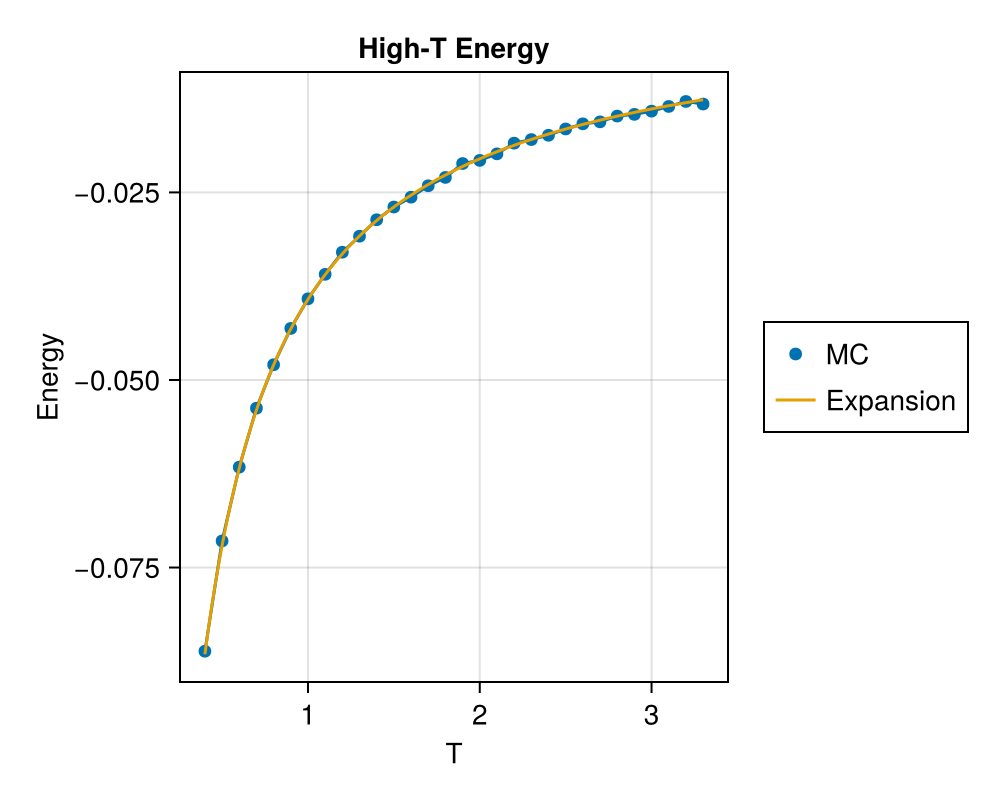

In [ ]:
fig = Figure(size=(500,400))
fig[1,1] = ax1 = Axis(fig, title="High-T Energy", xlabel="T", ylabel="Energy")
generate_plot!(ax1, :T, :Energy, results.data, label="MC")
lines!(ax1, min_T..max_T, getexpansion("afm_fe", 3), label="Expansion")
Legend(fig[1,2], ax1)
fig

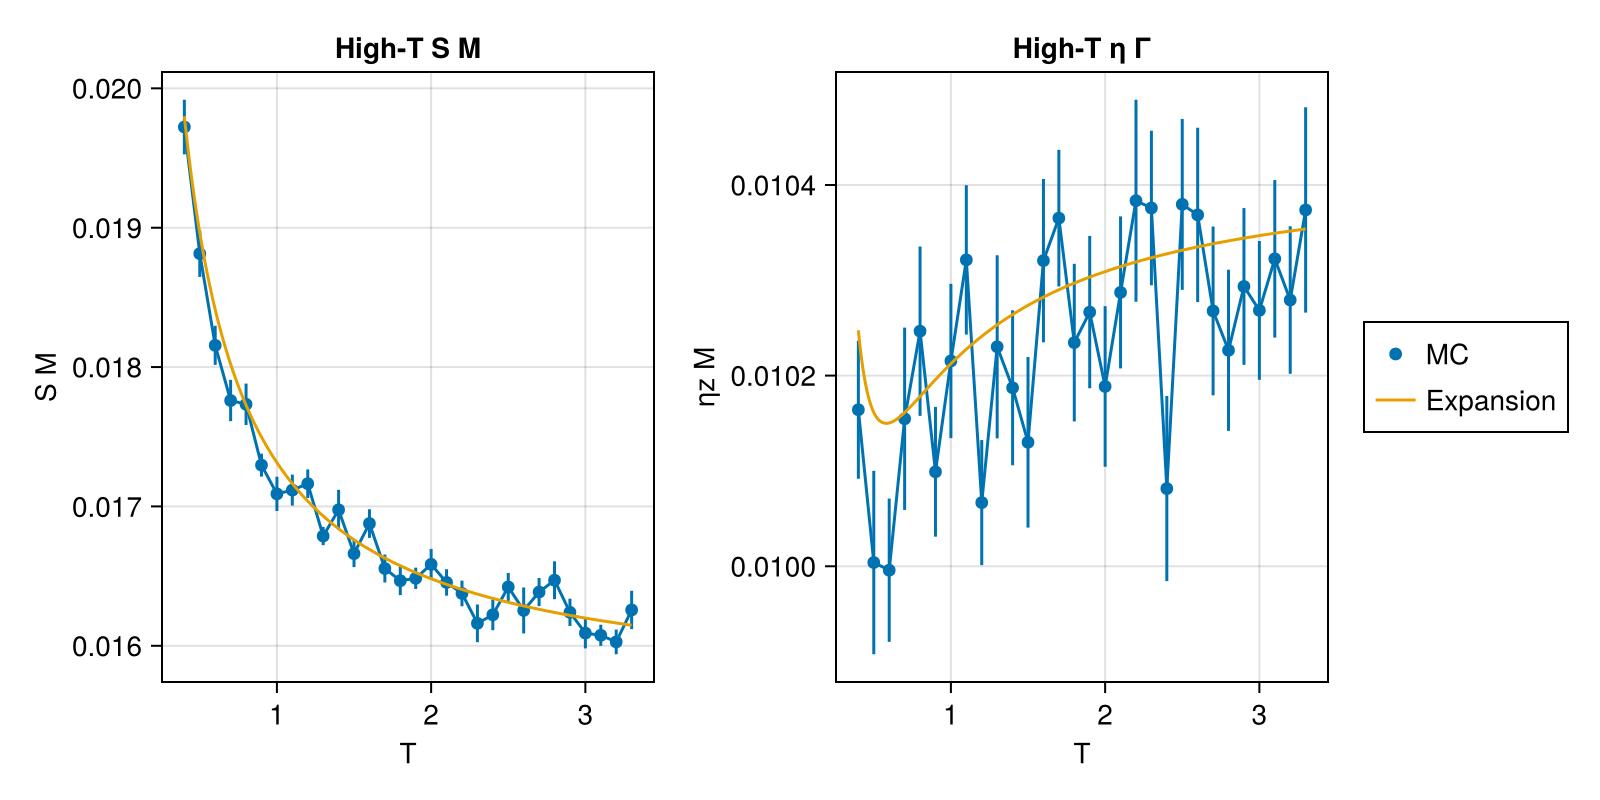

In [ ]:
fig = Figure(size=(800,400))
fig[1,1] = ax1 = Axis(fig, title="High-T S M", xlabel="T", ylabel="S M")
generate_plot!(ax1, :T, :sk_corr_M, results.data)
lines!(ax1, min_T..max_T, getexpansion("afm_fe", 3, "s"))
fig[1,2] = ax2 = Axis(fig, title="High-T η Γ", xlabel="T", ylabel="ηz M")
generate_plot!(ax2, :T, :ηk_corr_Γ, results.data, label="MC") do ηk
    real.(getindex.(ηk, 1, 1) + getindex.(ηk, 2, 2))
end
lines!(ax2, min_T..max_T, getexpansion("afm_fe", 3, "η"), label="Expansion")
Legend(fig[1,3], ax2)
fig

## AFM-AFE

In [42]:
results = JobResult("../jobs", "afm-afe-high-t")

JobResult("../jobs", "afm-afe-high-t", 20×51 DataFrame
 Row │ ηk_Γ                               ηk_corr_half_K                     M ⋯
     │ Array…                             Array…                             M ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…    ⋯
   2 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…  -
   3 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  -
   4 │ Complex{Measurement{Float64}}[5.…  Complex{Measurement{Float64}}[0.…  -
   5 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…    ⋯
   6 │ Complex{Measurement{Float64}}[-7…  Complex{Measurement{Float64}}[0.…
   7 │ Complex{Measurement{Float64}}[-8…  Complex{Measurement{Float64}}[0.…  -
   8 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…  -
  ⋮  │                 ⋮                                  ⋮          

In [43]:
max_T = maximum(results.data[:, :T])
min_T = minimum(results.data[:, :T])

0.3

In [44]:
all_data = load("expectations.jld2")
display([cumulant([measurement(all_data["afm_afe/HH$i"]) for i in 0:4],i) for i in 1:4])
display([cumulant([measurement(all_data["afm_afe/sH$i"]) for i in 0:4],i) for i in 1:4])
display([cumulant([measurement(all_data["afm_afe/ηH$i"]) for i in 0:4],i) for i in 1:4])

4-element Vector{Measurement{Float64}}:
 0.00092 ± 0.00074
  2.2089 ± 0.0016
   0.228 ± 0.008
  0.0043 ± 0.032

4-element Vector{Measurement{Float64}}:
  0.0069431 ± 2.0e-6
 -0.0003931 ± 5.9e-6
   0.015315 ± 1.3e-5
  -0.001123 ± 5.0e-5

4-element Vector{Measurement{Float64}}:
 0.0046273 ± 2.3e-6
  -3.59e-5 ± 4.9e-6
   0.01026 ± 1.2e-5
  0.000778 ± 4.2e-5

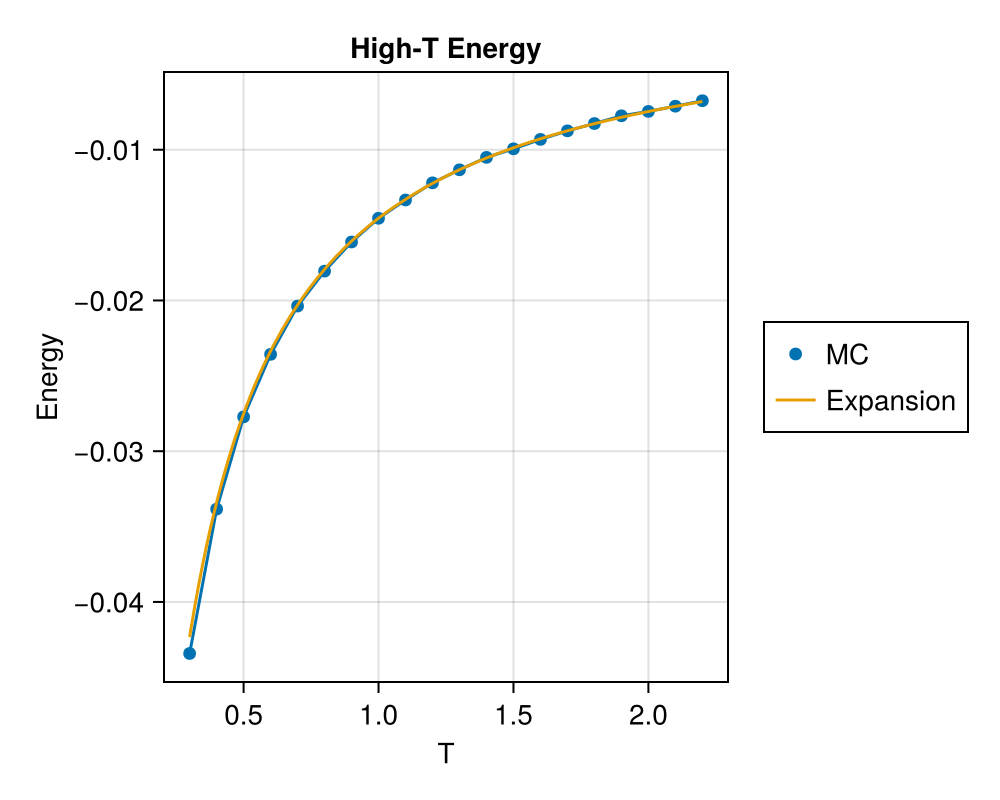

In [45]:
fig = Figure(size=(500,400))
fig[1,1] = ax1 = Axis(fig, title="High-T Energy", xlabel="T", ylabel="Energy")
generate_plot!(ax1, :T, :Energy, results.data, label="MC")
lines!(ax1, min_T..max_T, getexpansion("afm_afe", 2, L=12), label="Expansion")
Legend(fig[1,2], ax1)
save("plots/afm-afe-highT-energy.png", fig)
fig

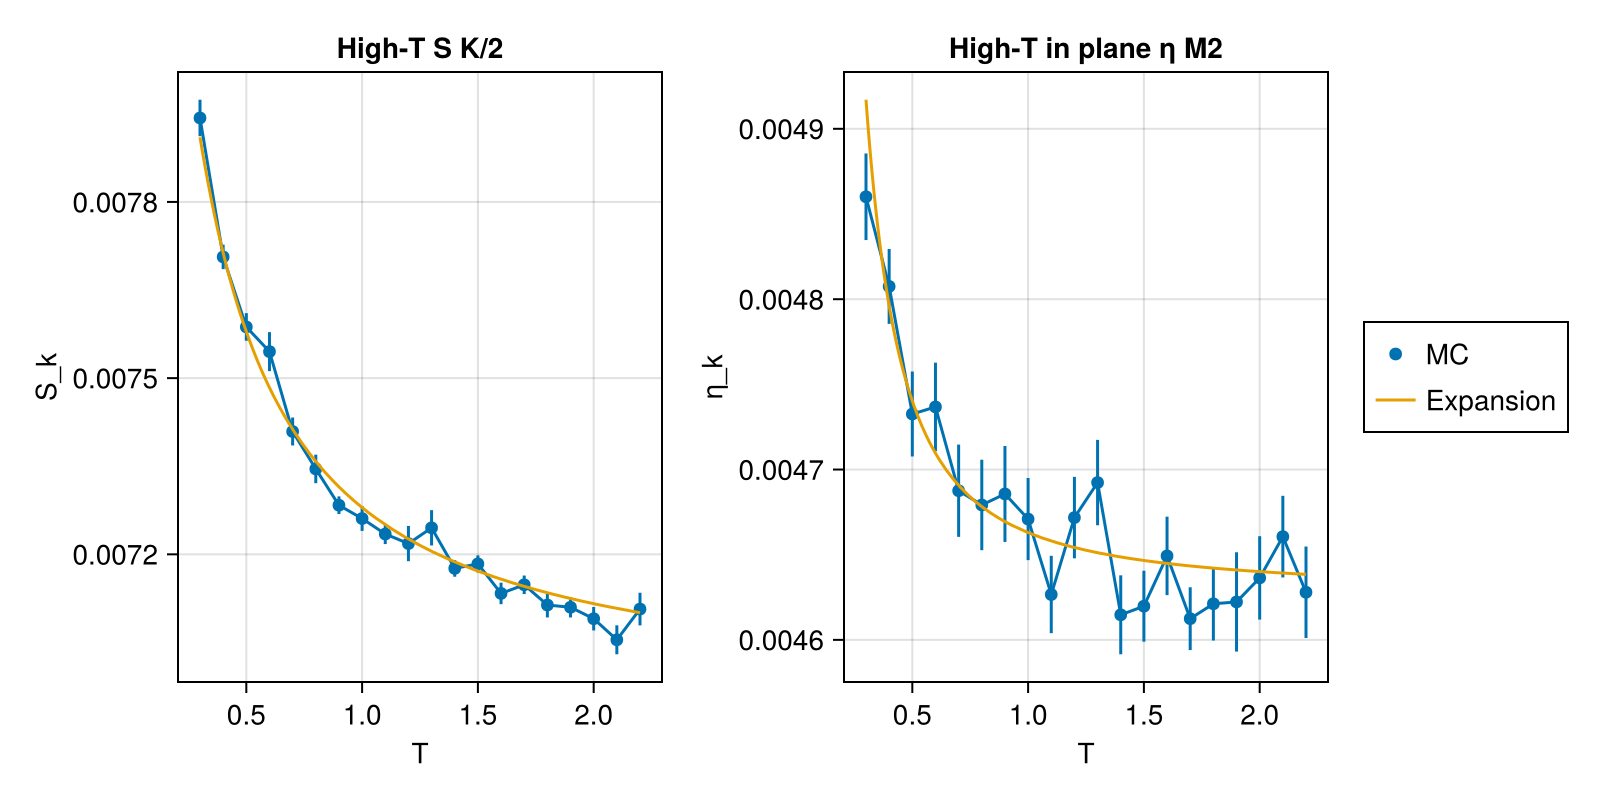

In [14]:
fig = Figure(size=(800,400))
fig[1,1] = ax1 = Axis(fig, title="High-T S K/2", xlabel="T", ylabel="S_k")
generate_plot!(ax1, :T, :sk_corr_half_K, results.data)
lines!(ax1, min_T..max_T, getexpansion("afm_afe", 3, "s"))
fig[1,2] = ax2 = Axis(fig, title="High-T in plane η M2", xlabel="T", ylabel="η_k")
generate_plot!(ax2, :T, :ηk_corr_M2, results.data, label="MC") do ηk
    real.(getindex.(ηk, 1, 1) + getindex.(ηk, 2, 2))
end
lines!(ax2, min_T..max_T, getexpansion("afm_afe", 3, "η"), label="Expansion")
Legend(fig[1,3], ax2)
save("plots/afm-afe-highT-spins.png", fig)
fig